# B-PEFT Demo — Bayesian Parameter-Efficient Fine-Tuning
**Pre-Defence Demo | IUT | Mainul**

Run cells top-to-bottom. GPU runtime recommended (Colab T4 is fine).

---
## 0. Setup — Clone / Pull Repo & Install

In [31]:
import os

REPO_NAME = "thesis"
REPO_URL = "https://github.com/notAvailable73/thesis.git"

# Check if we are already inside the repo directory
if os.path.basename(os.getcwd()) == REPO_NAME:
    print("Already in repo directory. Pulling...")
    os.system("git pull")
elif os.path.exists(REPO_NAME):
    print("Repo exists. Moving in and pulling...")
    os.chdir(REPO_NAME)
    os.system("git pull")
else:
    print("Cloning repo...")
    os.system(f"git clone {REPO_URL} {REPO_NAME}")
    os.chdir(REPO_NAME)

print("Current working directory:", os.getcwd())

Already in repo directory. Pulling...
Current working directory: /content/thesis


In [15]:
import os, importlib, src
os.chdir("/content/thesis")
os.system("git pull origin main")
importlib.invalidate_caches()
print("Done. Restart runtime if you changed existing files.")


Done. Restart runtime if you changed existing files.


In [4]:
# Install dependencies
!pip install -q -r requirements.txt

In [5]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


---
## Task 1 — Config

In [6]:
from src.config import CFG
print("Seed:", CFG.seed)
print("N-way:", CFG.num_classes, "  K-shot:", CFG.shots)
print("Feature dim:", CFG.feature_dim, "  Adapter rank:", CFG.adapter_rank)

Seed: 42
N-way: 5   K-shot: 5
Feature dim: 512   Adapter rank: 16


---
## Task 2 — Utilities

In [7]:
from src.utils import set_seed, get_device
set_seed(42)
device = get_device()
print("Device:", device)

Device: cuda


---
## Task 3 — Data (CIFAR-FS episode + SVHN OOD)

Downloads ~170 MB CIFAR-100 and ~60 MB SVHN on first run.

In [8]:
from src.data import get_cifar100_test, sample_episode, get_svhn_ood
from src.config import CFG

dataset = get_cifar100_test(CFG.data_root, CFG.image_size)
support_x, support_y, query_x, query_y = sample_episode(
    dataset, CFG.test_class_ids, CFG.num_classes,
    CFG.shots, CFG.query_per_class, CFG.seed
)
print("support_x:", support_x.shape)  # (25, 3, 224, 224)
print("query_x:  ", query_x.shape)    # (75, 3, 224, 224)

svhn_x = get_svhn_ood(CFG.data_root, CFG.image_size, CFG.ood_num_samples, CFG.seed)
print("svhn_x:   ", svhn_x.shape)     # (500, 3, 224, 224)

support_x: torch.Size([25, 3, 224, 224])
query_x:   torch.Size([75, 3, 224, 224])
svhn_x:    torch.Size([500, 3, 224, 224])


---
## Task 4 — Frozen ResNet18 Backbone

In [9]:
import torch
from src.backbone import build_frozen_resnet18

backbone = build_frozen_resnet18()
dummy = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    out = backbone(dummy)
assert out.shape == (2, 512)
frozen = all(not p.requires_grad for p in backbone.parameters())
assert frozen
print(f"Output shape: {out.shape}  |  All frozen: {frozen}")
print("OK")


Output shape: torch.Size([2, 512])  |  All frozen: True
OK


---
## Task 5 — Bottleneck Adapter

In [10]:
import torch
from src.adapter import BottleneckAdapter

adapter = BottleneckAdapter(512, 16)
x = torch.randn(4, 512)
out = adapter(x)
assert out.shape == (4, 512)
assert torch.allclose(out, x, atol=1e-6), "Adapter not identity at init!"
n_params = sum(p.numel() for p in adapter.parameters())
print(f"Adapter params: {n_params:,}  (expect ~16,912)")

Adapter params: 16,912  (expect ~16,912)


---
## Task 6 — Full Model (Backbone + Adapter + Head)

In [14]:
import torch
from src.model import BPEFTModel
from src.utils import count_trainable_params

model = BPEFTModel(num_classes=5, mode="evidential")
dummy = torch.randn(8, 3, 224, 224)
out = model(dummy)
assert out.shape == (8, 5)
assert (out >= 0).all()
n = count_trainable_params(model)
print(f"Output shape: {out.shape}")
print(f"All outputs >= 0: True")
print(f"Trainable params: {n:,}  (expect < 20,000)")


Output shape: torch.Size([8, 5])
All outputs >= 0: True
Trainable params: 19,477  (expect < 20,000)


---
## Task 7 — Losses (Evidential MSE + KL + Softmax CE)

In [16]:
import torch
from src.losses import evidential_mse_loss, softmax_ce_loss

evidence = torch.rand(4, 5) * 2
target_oh = torch.eye(5)[[0, 1, 2, 3]]
ev_loss = evidential_mse_loss(evidence, target_oh, num_classes=5, kl_weight=1.0)
print(f"Evidential loss: {ev_loss.item():.6f}  finite={ev_loss.isfinite().item()}")
assert ev_loss.isfinite()

logits = torch.randn(4, 5)
targets = torch.tensor([0, 1, 2, 3])
ce_loss = softmax_ce_loss(logits, targets)
print(f"CE loss:         {ce_loss.item():.6f}  finite={ce_loss.isfinite().item()}")
assert ce_loss.isfinite()

print("OK")


Evidential loss: 1.710531  finite=True
CE loss:         2.157985  finite=True
OK


---
## Task 9 — Training

Trains for 200 steps on the 5-way 5-shot support set.
Saves checkpoint to `checkpoints/model_{mode}.pt`.

In [32]:
# Train evidential model
!python -m src.train --mode evidential


Training mode: EVIDENTIAL  |  device: cuda
Trainable params: 19,477
  step   1/300  loss=1.6651  train_acc=0.200
  step  20/300  loss=0.0000  train_acc=1.000
  step  40/300  loss=0.0000  train_acc=1.000
  step  60/300  loss=0.0000  train_acc=1.000
  step  80/300  loss=0.0000  train_acc=1.000
  step 100/300  loss=0.0000  train_acc=1.000
  step 120/300  loss=0.0000  train_acc=1.000
  step 140/300  loss=0.0000  train_acc=1.000
  step 160/300  loss=0.0000  train_acc=1.000
  step 180/300  loss=0.0000  train_acc=1.000
  step 200/300  loss=0.0000  train_acc=1.000
  step 220/300  loss=0.0000  train_acc=1.000
  step 240/300  loss=0.0000  train_acc=1.000
  step 260/300  loss=0.0000  train_acc=1.000
  step 280/300  loss=0.0000  train_acc=1.000
  step 300/300  loss=0.0000  train_acc=1.000

Checkpoint saved: checkpoints/model_evidential.pt
Final train accuracy: 1.000


In [33]:
# Train softmax baseline
!python -m src.train --mode softmax


Training mode: SOFTMAX  |  device: cuda
Trainable params: 19,477
  step   1/300  loss=1.7944  train_acc=0.200
  step  20/300  loss=0.0005  train_acc=1.000
  step  40/300  loss=0.0000  train_acc=1.000
  step  60/300  loss=0.0000  train_acc=1.000
  step  80/300  loss=0.0000  train_acc=1.000
  step 100/300  loss=0.0000  train_acc=1.000
  step 120/300  loss=0.0000  train_acc=1.000
  step 140/300  loss=0.0000  train_acc=1.000
  step 160/300  loss=0.0000  train_acc=1.000
  step 180/300  loss=0.0000  train_acc=1.000
  step 200/300  loss=0.0000  train_acc=1.000
  step 220/300  loss=0.0000  train_acc=1.000
  step 240/300  loss=0.0000  train_acc=1.000
  step 260/300  loss=0.0000  train_acc=1.000
  step 280/300  loss=0.0000  train_acc=1.000
  step 300/300  loss=0.0000  train_acc=1.000

Checkpoint saved: checkpoints/model_softmax.pt
Final train accuracy: 1.000


---
## Task 8 — Metrics (sanity check on synthetic data)

In [34]:
# Task 8 sanity check
import torch, numpy as np
from src.metrics import accuracy, expected_calibration_error, brier_score, ood_auroc

probs = torch.softmax(torch.randn(50, 5), dim=-1)
targets = torch.randint(0, 5, (50,))
print(f"Accuracy : {accuracy(probs, targets):.3f}")
print(f"ECE      : {expected_calibration_error(probs, targets):.3f}")
print(f"Brier    : {brier_score(probs, targets, 5):.3f}")
id_s  = np.random.uniform(0.7, 1.0, 75)
ood_s = np.random.uniform(0.0, 0.4, 500)
print(f"OOD AUROC: {ood_auroc(id_s, ood_s):.3f}  (expect > 0.9)")


Accuracy : 0.260
ECE      : 0.193
Brier    : 0.900
OOD AUROC: 1.000  (expect > 0.9)


---
## Task 10 — Evaluation & Plots

In [35]:
!python -m src.evaluate


[EVIDENTIAL]
  Accuracy : 0.893
  ECE      : 0.526
  Brier    : 0.541
  OOD AUROC: 0.991
  Params   : 19,477

[SOFTMAX]
  Accuracy : 0.933
  ECE      : 0.040
  Brier    : 0.095
  OOD AUROC: 0.854
  Params   : 19,477

Saved: results/metrics.json
Saved: results/reliability_plot.png
Saved: results/ood_histogram.png
Saved: results/training_curve.png

Done.


In [36]:
import json
from IPython.display import Image, display

with open("results/metrics.json") as f:
    metrics = json.load(f)

print("=== RESULTS ===")
for mode in ["evidential", "softmax"]:
    m = metrics[mode]
    print(f"\n{mode.upper()}")
    print(f"  Accuracy : {m['accuracy']:.3f}")
    print(f"  ECE      : {m['ece']:.3f}")
    print(f"  Brier    : {m['brier']:.3f}")
    print(f"  OOD AUROC: {m['ood_auroc']:.3f}")

print("\nTrainable params:", metrics.get("trainable_params", {}))

=== RESULTS ===

EVIDENTIAL
  Accuracy : 0.893
  ECE      : 0.526
  Brier    : 0.541
  OOD AUROC: 0.991

SOFTMAX
  Accuracy : 0.933
  ECE      : 0.040
  Brier    : 0.095
  OOD AUROC: 0.854

Trainable params: {'evidential': 19477, 'softmax': 19477}


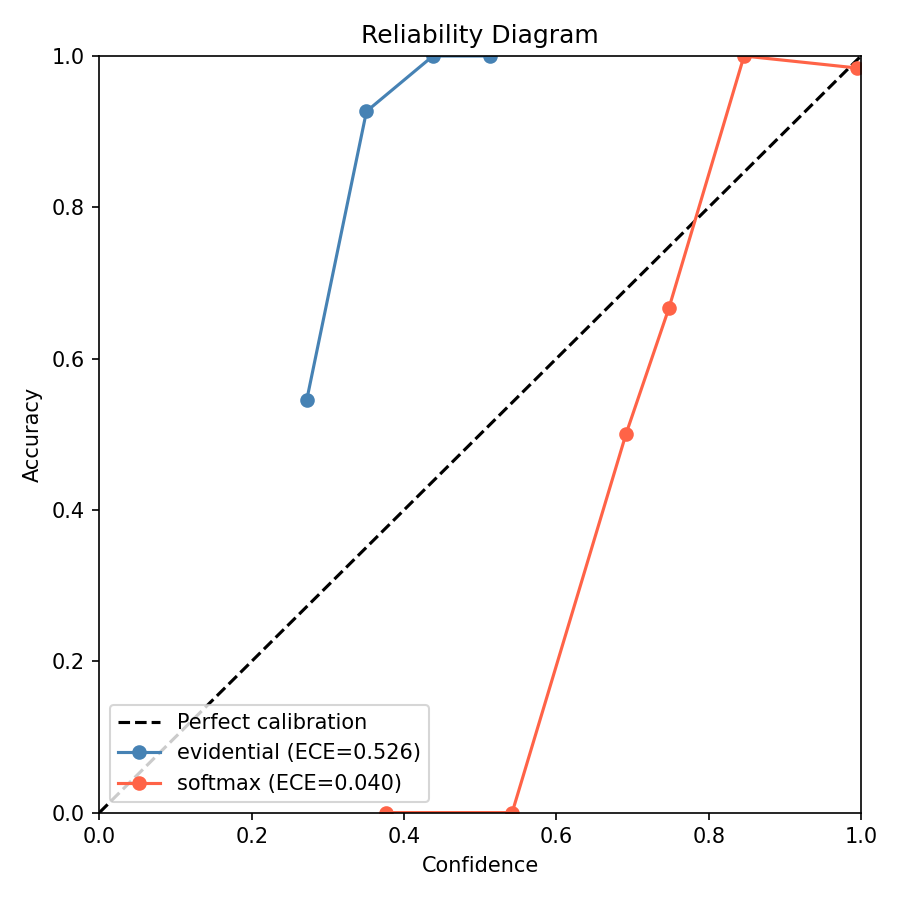

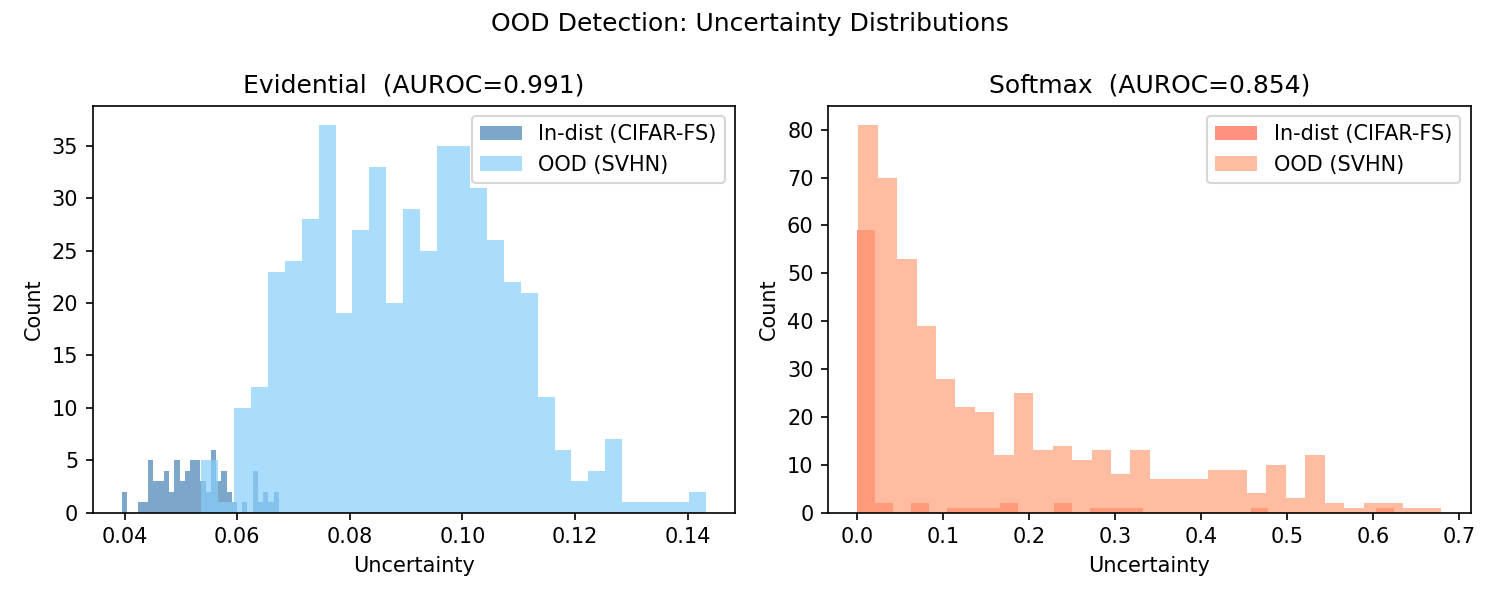

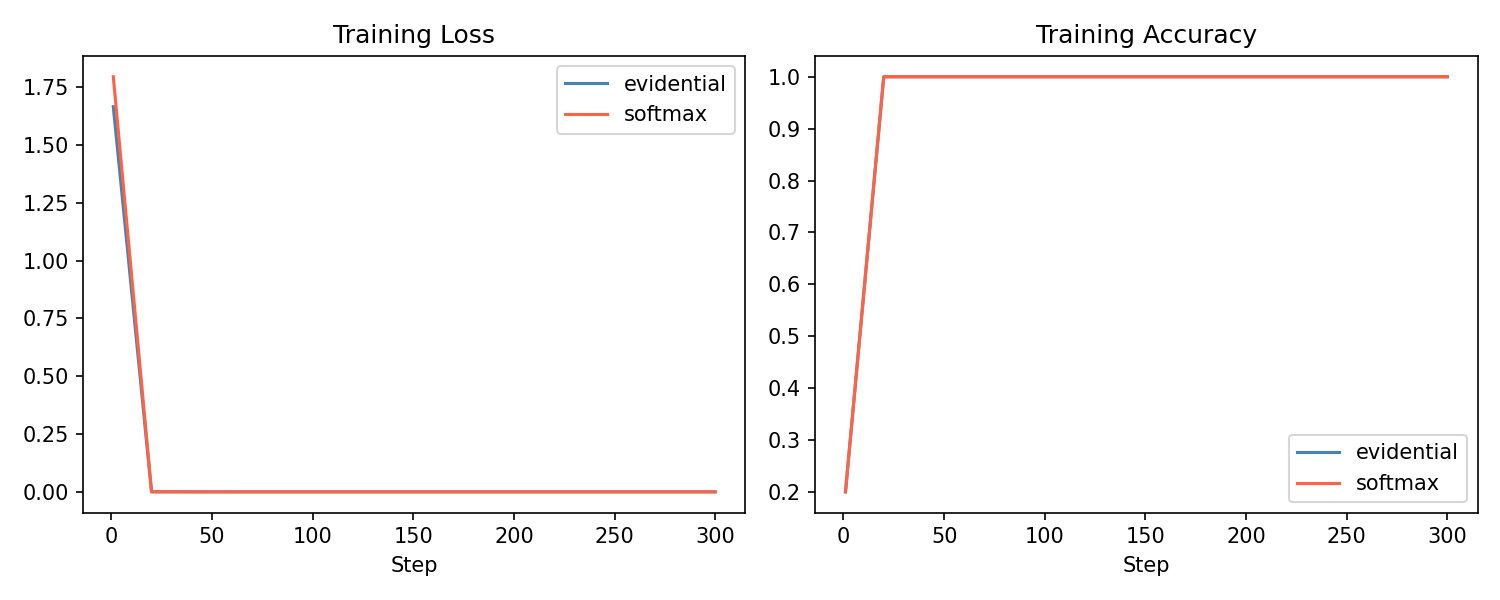

In [37]:
from IPython.display import Image, display
display(Image("results/reliability_plot.png"))
display(Image("results/ood_histogram.png"))
display(Image("results/training_curve.png"))

In [ ]:
from google.colab import files

to_download = [
    "results/metrics.json",
    "results/reliability_plot.png",
    "results/ood_histogram.png",
    "results/training_curve.png",
    "results/slides_outline.md",
]

for f in to_download:
    files.download(f)
